In [11]:
import spacy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances
import matplotlib as mpl

nlp = spacy.load("en_core_web_md")

text = "laptop computer coffee tea water liquid dog cat kitty"
words = text.split()

vectors = []

for w in words:
    vec = nlp(w).vector
    vectors.append(vec)

V = np.array(vectors, dtype=np.float32)
cos_sim = cosine_distances(V)

cos_dist = 1 - cos_sim

words_y = words[::-1]
cos_dist_y = cos_dist[::-1, :]

laptop_vec = V[0]
soufian = laptop_vec[:20].sum()

print("Laptop vector shape:", laptop_vec.shape)
print("Sum of first 20 values:", soufian)

Laptop vector shape: (300,)
Sum of first 20 values: 5.710388


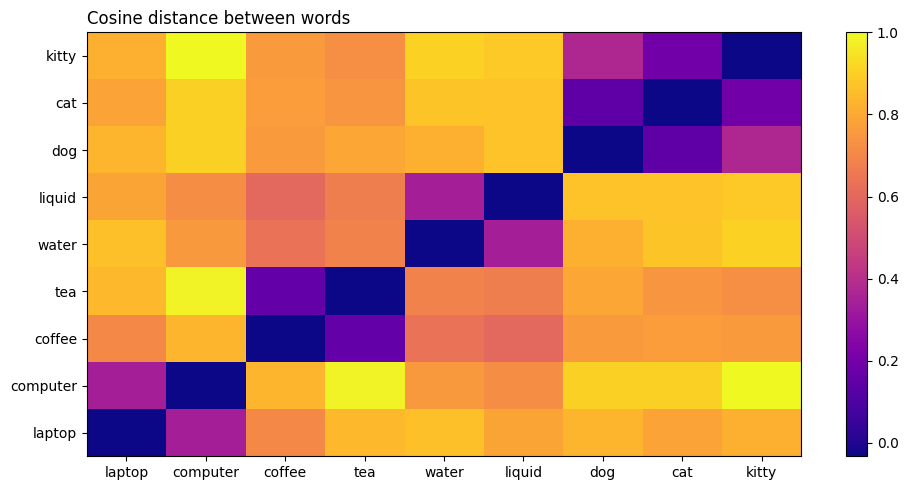

In [12]:


fig, ax = plt.subplots(figsize=(10, 5))

img = ax.imshow(
    cos_dist_y,
    interpolation="nearest",
    cmap="plasma_r",
    aspect="auto"
)

ax.set_title("Cosine distance between words", loc="left")
norm = mpl.colors.Normalize(
    vmin=cos_dist_y.min(),
    vmax=cos_dist_y.max()
)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="plasma")
sm.set_array([])
fig.colorbar(sm, ax=ax)
ax.set_xticks(range(len(words)))
ax.set_xticklabels(words, rotation=0)
ax.set_yticks(range(len(words_y)))
ax.set_yticklabels(words_y)

plt.tight_layout()
plt.show()
